# How to use Gymnasium
Gymnasium is a toolkit comprised with several environments aimed at testing and comparing diferent reinforcement learning algorithms. Gymnasium supersedes OpenAI's Gym toolkit

They provide 7 groups of environments:

* Algorithms: Text-based environments to train how to do computations.
* Atari: Environments based on atari games like pong.
* Box2D: 2D control task environments.
* Classic control: Classic problems present in RL literature.
* MuJoCo: 3D continuous control task environments.
* Robotics: 3D environments featuring a robot arm or robot hand.
* Toy text: Simple environments in which the state is rendered  as text.

For more information check the [Gymnasium](https://gymnasium.farama.org/).

## Installing Gymnasium on Google Colab

In [1]:
!pip install gymnasium

## Helper functions for Google Colab

In [2]:
# Video management imports
import cv2
import matplotlib.pyplot as plt

# Check if we running in Google Colab or Jupyter Notebook
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab')
    # Do you need to connect with Google Drive? Uncomment the next two lines
    # from google.colab import drive
    # drive.mount('/content/drive')
    # This auxiliary function simplifies the visualization of OpenCV Images
    from google.colab.patches import cv2_imshow
else:
    print('Running in Jupyter Notebook')
    # This auxiliary function simplifies the visualization of OpenCV Images
    def cv2_imshow(img, title=''):
        if img.ndim > 2:
            img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img)
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()
        else:
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img, cmap='gray')
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()


Running in Jupyter Notebook


## Gym Dependencies

In [3]:
import gymnasium as gym
print(gym.__version__)

1.2.0


## Instantiate the Environment
At this point you call the method `make` of the gym class to instantiate the desired environment and arguments if required.

In [4]:
env = gym.make('Blackjack-v1')

In this case the environment is a blackjack card game.

In this game the player's goal is to obtain cards that sum to as close as possible to 21 without going over.

The game starts with the dealer having one face up and one face down card and the player having two face up cards. The player has two possibilities:
- Hit (get another card)
- Stick (stay with the cards he already has).
If the sum of the player's cards is over 21, the player busts.

After the player sticks, the dealer reveals his facedown card, and draws until the sum is 17 or greater. If the dealer goes bust the player wins.

If neither player nor dealer busts, the outcome (win, lose, draw) is decided by whose sum is closer to 21.

The reward for winning is +1, drawing is 0, and losing is -1. If the player wins with a natural blackjack (an A and a 10), the winning is worth +1.5.

## Checking the State and Action Spaces

To check the shape of the state space, simply call `observation_space` on the environment variable:

In [5]:
env.observation_space

Tuple(Discrete(32), Discrete(11), Discrete(2))

For this environment the observation space is:

1. The sum of the 2 cards in the player's hand. The sum is at most 31.
2. The card that the dealer is currently showing. The cards' values are
 - Ace may have a value of 10 (usable ace) or 1 (non usable ace).
 - Number cards keep their values, from 2 to 10.
 - Face cards J, Q, and K have a value of 10.
3. If the player has an usable ace or not.



To get a random observation call the `sample()` method on the `observation_space`:

In [8]:
env.observation_space.sample()

(np.int64(23), np.int64(2), np.int64(1))

In [12]:
import cv2
import matplotlib.pyplot as plt

# Check if we running in Google Colab or Jupyter Notebook
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab')
    # Do you need to connect with Google Drive? Uncomment the next two lines
    # from google.colab import drive
    # drive.mount('/content/drive')
    # This auxiliary function simplifies the visualization of OpenCV Images
    from google.colab.patches import cv2_imshow
else:
    print('Running in Jupyter Notebook')
    # This auxiliary function simplifies the visualization of OpenCV Images
    def cv2_imshow(img, title=''):
        if img.ndim > 2:
            img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img)
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()
        else:
            # view the image in its natural size
            plt.figure(figsize=(img.shape[1], img.shape[0]), dpi=1)
            plt.imshow(img, cmap='gray')
            plt.title(title)
            plt.xticks([]), plt.yticks([])
            plt.show()

# Helper functions to save videos and images
def save_video(img_array, path='/content/test.mp4'):
  height, width, layers = img_array[0].shape
  size = (width, height)
  out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'MP4V'), 15, size)
  if out.isOpened():
    for i in range(len(img_array)):
      bgr_img = cv2.cvtColor(img_array[i], cv2.COLOR_RGB2BGR)
      out.write(bgr_img)
    out.release()
    print('Video saved.')
  else:
    print(f'Could not save video path: {path}')

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def to_html_video(img_array):
  # Function to update each frame in the animation
  def update_frame(i):
      frame.set_data(img_array[i])
      return frame,

  # Set up the plot
  # Your list of images
  # images = [img1, img2, img3, ...]
  # Assuming all images have the same shape as the first image
  img_height, img_width = img_array[0].shape[:2]

  # Set up the figure size based on the image size with a desired DPI
  dpi = 100
  fig_width = img_width / float(dpi)
  fig_height = img_height / float(dpi)
  fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
  ax.axis('off')

  frame = ax.imshow(img_array[0])

  # Create an animation
  ani = FuncAnimation(fig, update_frame, frames=len(img_array), blit=True)

  # To display the animation inline, convert it to HTML and display it
  html = HTML(ani.to_html5_video())
  plt.close(fig)
  return html

Running in Jupyter Notebook


The same goes for the action space:

In [9]:
env.action_space

Discrete(2)

In [10]:
env.action_space.sample()

np.int64(0)

## Resetting the Environment

Resetting the environment means to begin a **new episode** and get the **starting observation**. With Gym, use the method `reset()` on the environment instance.

In [11]:
observation, info = env.reset()
print(observation)

(21, 10, 1)


## Performing an Action
To make the agent act on the environment, use the method `step(action)` on the environment instance. Action has to be one of the valid actions of the environment.

In the case of blackjack game, we have hit = 1 and stick = 0.

The `step(action)` method returns the following:
- A new observation.
- The reward of the last action.
- Two booleans variable to check if the episode is finished or truncated (stoped for other reasons).
- Extra info (it depends on the Gym environment). For blackjack is an empty dict.

In [12]:
observation, reward, terminated, truncated, info = env.step(0)
print(f'{observation}, {reward}, {terminated}, {truncated}, {info}')

(21, 10, 1), 0.0, True, False, {}


## A Random Agent

Let's test this environment with a random agent, in which each action (hit or stick) has a probability of 50%.

The next code represent the basic loop required to generate an episode in which the agent interacts with the environment.

In [13]:
# Reset the environment
observation, info = env.reset()

# Print the initial observation
print(f"Initial observation: {observation}")

# Iterate until done
done = False
while not done:
    # Choose a random action from the action space. In future examples
    # we will use smarter ways to decide which action to take :)
    action = env.action_space.sample()

    # Perform a step by executing the selected action
    observation, reward, terminated, truncated, info = env.step(action)

    # check if we are done the episode
    done = terminated or truncated

    # Print the information gathered
    print(f'Step: {observation}, {reward}, {terminated}, {truncated}, {info}')
env.close()

Initial observation: (10, 5, 0)
Step: (17, 5, 0), 0.0, False, False, {}
Step: (24, 5, 0), -1.0, True, False, {}


## Viewing an environment

Many environments provide a visual representation of their state. This representation is usually an image or text.

There are many ways to visualize and manipulate images in Google colab/Jupyter notebook. One of them is through OpenCV. Just import to the project ``cv2`` to convert the image to BGR (to visualize with OpenCV) and  ``cv2_imshow`` to show the image.

C:\Users\enriq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


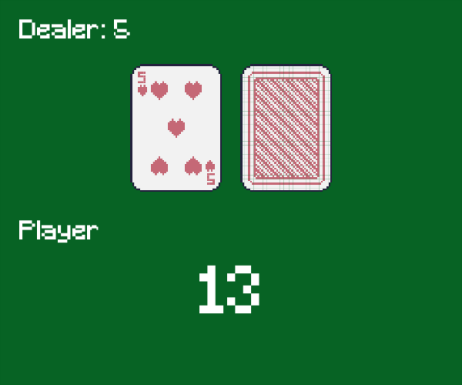

In [14]:
env = gym.make('Blackjack-v1', render_mode='rgb_array')
observation, _ = env.reset()
image = env.render()
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
cv2_imshow(image)

Much nicer :)

Let's try a second environment called *Acrobot*

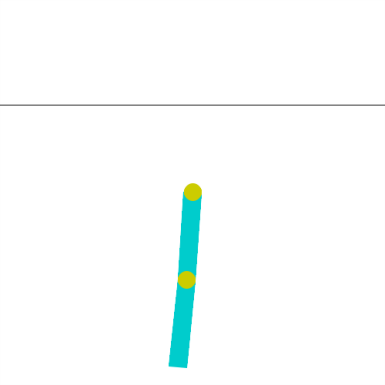

In [15]:
env = gym.make('Acrobot-v1', render_mode = 'rgb_array')
observation, _ = env.reset()
image = env.render()
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
cv2_imshow(image)

## Helper to Save Videos
We are going to define a function that generates a video out of a list of frames. We will use this helper function in all notebooks:

In [19]:
# Video management imports
import cv2
from IPython.display import Video
from IPython.display import HTML

# Helper functions to save videos and images
def save_video(img_array, path:str='videos'):
  height, width, layers = img_array[0].shape
  size = (width, height)
  out = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*'MP4V'), 15, size)
  if out.isOpened():
    for i in range(len(img_array)):
      bgr_img = cv2.cvtColor(img_array[i], cv2.COLOR_RGB2BGR)
      out.write(bgr_img)
    out.release()
    print('Video saved.')
  else:
    print(f'Could not save video path: {path}')

Once we have defined this function, we can run again an episode loop. In this case, we can simply store the image generated by the environment into a list. We will use this list as frames for image generation.

In [20]:
# The same random agent but saving an image array
observation, info = env.reset()
done = False
img_array = []
while not done:
    action = env.action_space.sample() # Choose a random action
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    image = env.render()
    img_array.append(image)
env.close()

We can call save_video to store the file:

In [21]:
video_filename = 'videos'
# Remember to create a 'video' folder
save_video(img_array, path=video_filename)

Could not save video path: videos


Now let's define a second helper function that converts a video in mp4 format to HTML, so that we can embed the result in our notebook:

In [22]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def to_html_video(img_array):
  # Function to update each frame in the animation
  def update_frame(i):
      frame.set_data(img_array[i])
      return frame,

  # Set up the plot
  # Your list of images
  # images = [img1, img2, img3, ...]
  # Assuming all images have the same shape as the first image
  img_height, img_width = img_array[0].shape[:2]

  # Set up the figure size based on the image size with a desired DPI
  dpi = 100
  fig_width = img_width / float(dpi)
  fig_height = img_height / float(dpi)
  fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
  ax.axis('off')

  frame = ax.imshow(img_array[0])

  # Create an animation
  ani = FuncAnimation(fig, update_frame, frames=len(img_array), blit=True)

  # To display the animation inline, convert it to HTML and display it
  html = HTML(ani.to_html5_video())
  plt.close(fig)
  return html

RuntimeError: Requested MovieWriter (ffmpeg) not available

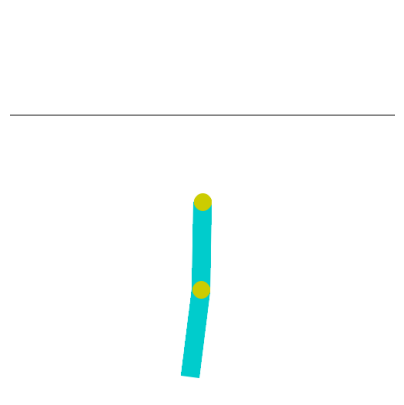

In [24]:
to_html_video(img_array)

Let's explore the Acrobot environment. Let's start by analyzing its observation space:

In [ ]:
env.observation_space

Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)

In this case we have 6 continuous observations (float32). The first vector indicates the lower limit values for this variables, while the second indicated the upper limits.

In [ ]:
env.action_space

Discrete(3)

In this case we have 3 discrete actions that we can perform.

Let's try another environment: Pendulum

In [ ]:
env = gym.make("Pendulum-v1", render_mode='rgb_array')

# Let's get some info about the observation and action spaces
print(env.observation_space)
print(env.action_space)

# A random Pendulum
observation, info = env.reset()
done = False
img_array = []
while not done:
    action = env.action_space.sample() # Choose a random action
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    image = env.render()
    img_array.append(image)
env.close()

Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Box(-2.0, 2.0, (1,), float32)


In [ ]:
to_html_video(img_array)


As we can see above Pendulum has both a continuous action and observation space. The observation space in the position of pendulum:
- x, y coordinates of the end of the pendulum in meters.
- the angle in radians

The action is a torque tau in Nm.



# Other Environments

Let's try another environment: LunarLander. LunarLander as many RL is defined using a simulation. In this case the simulation is based on the Box2D library. This library provides primitives to simulate complex mechanisms in a physically realistic way.

In [ ]:
!pip install swig
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp310-cp310-linux_x86_64.whl size=2376424 sha256=499cffe60aa22421305c1d8d5a23914586927d8148a510a8e5567fbda7959415
  Stored in directory: /root/.cache/pip/wheels/db/8f/6a/eaaadf056fba10a98d986f6dce954e6201ba3126926fc5ad9e
Successfully built box2d-py


In [ ]:
env = gym.make("LunarLander-v3", render_mode='rgb_array')

# Let's get some info about the observation and action spaces
print(env.observation_space)
print(env.action_space)

# A random Pendulum
observation, info = env.reset()
done = False
img_array = []
while not done:
    action = env.action_space.sample() # Choose a random action
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    image = env.render()
    img_array.append(image)
env.close()

to_html_video(img_array)

Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Discrete(4)


# Custom Environment

One of the advantages of using Gymnasium and RL-based algorithms based on the OpenAI's Gym API is that we can easily create our own environments.

## Example 1: Two Arm Bandit

This environment has a limited set of 5 discrete states (pos 0 to 4). The agent always starts at the center (pos=2). It has only two posible actions: move right (action=1) or left (action=0).

The rewards can be any value from -100 to 100.

In [ ]:
from gymnasium import spaces
import numpy as np

# Any environment mush inherit the gym.Env class
class TwoArmedBanditEnv(gym.Env):
    # We define the render modes for our environment. In this case it's only text
    # or 'human' in Gymnasiums.
    metadata = {'render.modes': ['human']}

    # The __init__ function initializes the environment
    def __init__(self):
        # We have to always call the base class initialization.
        super(TwoArmedBanditEnv, self).__init__()

        # Then we set-up some mandatory variables:
        # - the reward range
        # - the action space
        # - the observation space
        self.reward_range = (-100.0, 100.0)
        self.action_space = spaces.Discrete(2) # Two actions: left and right
        self.observation_space = spaces.Discrete(5) # 5 posible observation values

        # Finally in this simple example we define explicitly the rewards for
        # each state. Usually this is computed and can depend also the action taken
        self.rewards = np.array([+100, -10, 0, -5, -100])

    # The reset function performs any initialization required to return the
    # environment to a valid initial state. This function also returns a tuple
    # containing the initial observations, and optionally additional information
    # that could be relevant for the environment.
    def reset(self):
        # In this case we return the agent to the initial state
        self.current_pos = 2 # usually randomized
        # Define the environment observations, in this case the agent's position
        observations = (self.current_pos)
        # Return the observations and any additional information
        return observations, None

    # The step function performs the actions provided by the agent changing the
    # internal state of the environment as needed. It also determines if the
    # episode has terminated. In this case checking if we are at any end of initial
    # or final position.
    # It also defines the current observation and reward.
    def step(self, action):
        # 1.st we perform the action
        if action == 0: # Move Left
            self.current_pos -= 1
        if action == 1: # Move right
            self.current_pos += 1

        # Check if the episode has terminated. In this case, positions 0 and 4 are final
        terminated = ((self.current_pos == 0) or (self.current_pos == 4))
        truncated = False
        # Define the observations
        observations = (self.current_pos)
        # Define the reward
        reward = self.rewards[self.current_pos]
        #Return all the information in the correct order:
        # (observations), reward, terminated, truncated, info
        return observations, reward, terminated, truncated, None

    # The render function represents the environment.
    # In this case we represent is as text, marking with an asterisk '*' the
    # current position of the agent.
    def render(self):
        output = ['_','_','_', '_', '_']
        output[self.current_pos]='*'
        print(output)

If we were working on a desktop computer with Python modules (.py files) we could register our environment and create it using the function `gym.make`. This is not possible in Colab or Jupyter. The following snippet shows how this feature could be used:

```python
from gymnasium.envs.registration import register

register(
    id='TwoArmedBandit-v0',
    entry_point='path.to.module:TwoArmedBanditEnv',
)

env = gym.make("TwoArmedBandit-v0", render_mode='human')
```

In Colab we can create the environment directly, using its class constructor. The next code shows how we could use this environment with a random agent. Notice that the code for the random agent remains the same as before:

In [ ]:
env = TwoArmedBanditEnv()

# Let's get some info about the observation and action spaces
print(env.observation_space)
print(env.action_space)

# Let's simulate a random agent
observation, info = env.reset()
done = False
rewards = []
while not done:
    action = env.action_space.sample() # Choose a random action
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    rewards.append(reward)
    env.render()

env.close()
print(f"Rewards: {rewards}, accumulated: {sum(rewards)}")


Discrete(5)
Discrete(2)
['_', '*', '_', '_', '_']
['_', '_', '*', '_', '_']
['_', '*', '_', '_', '_']
['*', '_', '_', '_', '_']
Rewards: [-10, 0, -10, 100], accumulated: 80




## Example 2: BallEnv

Let's try to create a second environment. This environment represents a 2D space where a ball moves. The environment state can be visualized using an image.

In this example the environment simulates a ball. Depending on the action performed the ball will go updwards or it will fall.

In [ ]:
import math

class BallEnv(gym.Env):
    # The render mode is 'rgb_array' to indicate that we are representing ir as
    # an image
    metadata = {'render.modes': ['rgb_array']}

    # Let's define the basic properties of the environment with the initializer
    def __init__(self):
        # Call the base function functionality
        super().__init__()

        # Define the basic variables, reward_range, action_space and observation_space
        self.reward_range = (-1.0, 1.0)
        # The Box class defines continuous spaces of N-dimensions.
        # For each dimension we can define its minimum and maximun valid values,
        # in this case, we have only one dimension with values in [0,2]
        self.action_space = spaces.Box(low=np.array([0]), high=np.array([2]), dtype=np.float32)
        # In the case of observations we also have one dimension, with values
        # valid in the interval [0, 10]
        self.observation_space = spaces.Box(low=np.array([0]), high=np.array([20]), dtype=np.float32)

        # Let's define the initial properties of the Ball
        self.BALL_RADIUS = 0.1

        self.y = 10

    # The reset functions sets the position of the ball randombly within the
    # observation space
    def reset(self, seed=None, options=None):
        # Reset the state of the environment to an initial state
        self.y = np.random.rand()*10
        # Return the observations and additional information, usually a ditionary
        return np.array([self.y]), {}

    # Perform a simulation step
    def step(self, action):
        self.y += action[0] # We simply add the action
        self.y -= 1      # And decay to move to the ground as if falling

        # Check if the episode is finished. In this case we consider that the
        # episode is finisihed when the position of the ball is outside the
        # range (0, 20)
        terminated = False
        truncated = False

        if self.y > 20 or self.y < 0:
            terminated = True

        # Define a reward
        reward = - math.fabs(self.y-10)

        # Define additional info for the step. Empty in this case
        info = {}

        # Return step data: (observations), reward, terminated, truncated, info
        return np.array([self.y]), reward, terminated, truncated, info

    # We will create an image to render the environment using OpenCV. Any library
    # that generates images as np.ndarrays could be used.
    def render(self):
        # We will define a helper function to scale the coordinates son they
        # look nice on the image
        SCALE = 20
        def t(x,y):
            return (320 + int(SCALE*x), 470 - int(SCALE*y))

        # Generate a color image of 640x480, initialized to white
        image = np.ones((480, 640, 3), dtype=np.uint8 )*255

        # Draw the ball as a circle. Use the helper function t() to scale the
        # coordinates.
        cv2.circle(image, t(0, self.y), int(SCALE*self.BALL_RADIUS), (0, 0, 255))
        # Draw the bottom-line
        cv2.line(image, t(-10, 0), t(10, 0), (0.2, 0, 0), 2)
        # Draw the mid-line
        cv2.line(image, t(-1, 10), t(1, 10), (0.2, 0, 0), 1)
        # Draw the top-line
        cv2.line(image, t(-1, 20), t(1, 20), (0.2, 0, 0), 2)

        return image

Once defined, we can use the environment as usual with our random agent. We will store the image of every step to generate a video and visualize our environment.

In [ ]:
env = BallEnv()

# Let's get some info about the observation and action spaces
print(env.observation_space)
print(env.action_space)

# A random agent
observation, info = env.reset()
done = False
rewards = []
imgs = []
while not done:
    action = env.action_space.sample() # Choose a random action
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    rewards.append(reward)
    img = env.render()
    imgs.append(img)

env.close()
print(f"Rewards: {rewards}, accumulated: {sum(rewards)}")

to_html_video(imgs)

Box(0.0, 20.0, (1,), float32)
Box(0.0, 2.0, (1,), float32)
Rewards: [-7.146221165041354, -6.78519392428818, -7.249363068918612, -7.7975891870063805, -8.440873686651614, -8.105748478750613, -7.359336797575381, -7.462567393164065, -8.340732951144602, -7.707114596347239, -7.468470592479136, -7.626580853442576, -7.314267535190012, -6.605538268069651, -6.002708334903147, -5.084037442187693, -5.8777378839057945, -6.173616353849795, -6.954761211256411, -7.9352817409289145, -8.7598270796788, -8.144927325154569, -8.94549066057327, -8.086928429509427, -8.490871372128751, -7.873613181020048, -7.3542953156483435, -6.714369954968717, -6.023911776448514, -6.792005645538595, -6.706729041839864, -6.019805299545553, -5.576609598900106, -6.4486988656771445, -5.787110316063192, -6.6977023952257895, -6.955005037094381, -7.943492016251113, -8.300468584949996, -9.11798723643544, -10.004657281990077], accumulated: -300.18224787974316
